Link for Datset:
- https://drive.google.com/file/d/1QpchSL6pCATzESUIplHBVKil6rlVGlm4/view?usp=sharing

# Loading required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Dataset

In [ ]:
# Load the reviews dataset from Google Drive
df = pd.read_csv("Reviewsdrive.csv")

In [ ]:
# Display the columns in the DataFrame
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [ ]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [ ]:
# Display the shape of the DataFrame
df.shape

(568454, 10)

# Data Cleaning

In [ ]:
# Filter out rows where the 'rating' column is equal to 3 as we are classifying reviews to be positive or negative.
# This can come as moderate rating.

df_filtered = df[df['Score'] != 3]

# Verify the shape of the filtered DataFrame
print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape (without score = 3): {df_filtered.shape}")


Original DataFrame shape: (568454, 10)
Filtered DataFrame shape (without score = 3): (525814, 10)


In [ ]:
# Modify the existing 'score' column to have 'positive' or 'negative' based on the condition
df_filtered['Score'] = df_filtered['Score'].apply(lambda x: 'positive' if x > 3 else 'negative')

#Verify the changes
print(df_filtered[['Score']].head())


      Score
0  positive
1  negative
2  positive
3  negative
4  positive


<ipython-input-151-4f7ff5be0b21>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Score'] = df_filtered['Score'].apply(lambda x: 'positive' if x > 3 else 'negative')


In [ ]:
# Display the count of null values in each column of the filtered DataFrame
df_filtered.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,25
Text,0


- As the null values in both ProfileName and Summary are only 25, which is not really comparable to the total values of each, These can be dropped.

In [ ]:
# Drop rows with missing ProfileName or Summary
df_filtered = df_filtered.dropna(subset=['ProfileName', 'Summary'])

# Verify that missing values are gone
df_filtered.isnull().sum()


,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [ ]:
# Display the first 5 rows of the filtered DataFrame
df_filtered.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,positive,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,negative,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,positive,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,negative,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,positive,1350777600,Great taffy,Great taffy at a great price. There was a wid...


- Let us explore the other columns of the dataframe.
- This is to look at the 'Time' column.

In [ ]:
# Display the first 5 entries of the 'Time' column in the filtered DataFrame
print(df_filtered['Time'].head())


0    1303862400
1    1346976000
2    1219017600
3    1307923200
4    1350777600
Name: Time, dtype: int64


- The `Time` column contains Unix timestamps, representing seconds since January 1, 1970, which are not human-readable.  
- Using `pd.to_datetime(unit='s')`, timestamps are converted into standard datetime objects for better readability and usability.  
- This enables flexible time-based operations like filtering, grouping, and extracting components (e.g., year, month, day).  
- Displaying the first few rows with `head()` verifies that the conversion was successful.  

In [ ]:
# Convert Time column to datetime
df_filtered['Time'] = pd.to_datetime(df_filtered['Time'], unit='s')

#Display the first few rows to see the converted dates
print(df_filtered['Time'].head())


0   2011-04-27
1   2012-09-07
2   2008-08-18
3   2011-06-13
4   2012-10-21
Name: Time, dtype: datetime64[ns]


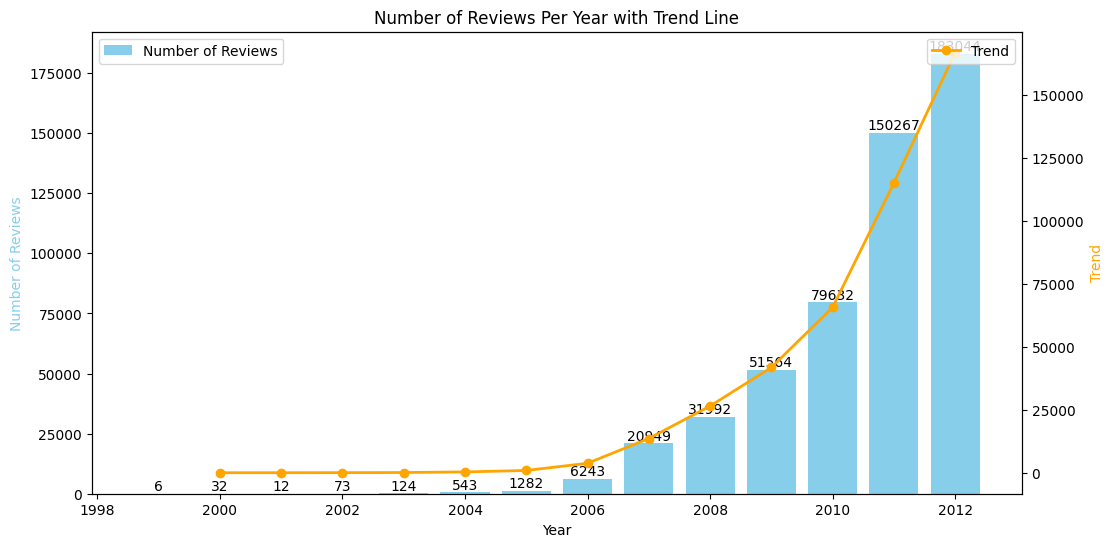

In [ ]:
import matplotlib.pyplot as plt

# Extract the year from the 'Time' column
df_filtered['Year'] = df_filtered['Time'].dt.year

# Count the number of reviews for each year
reviews_per_year = df_filtered['Year'].value_counts().sort_index()

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bar chart for number of reviews
bars = ax1.bar(reviews_per_year.index, reviews_per_year.values, color='skyblue', label='Number of Reviews')

# Add title and labels
ax1.set_title('Number of Reviews Per Year with Trend Line')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Reviews', color='skyblue')

# Annotate the number of reviews on top of each bar
for bar in bars:
    ax1.annotate(bar.get_height(),
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 ha='center', va='bottom')

# Create a second y-axis for the trend line
ax2 = ax1.twinx()

# Calculate and plot the trend line (rolling mean)
trend = reviews_per_year.rolling(window=2).mean()
ax2.plot(reviews_per_year.index, trend, color='orange', marker='o', label='Trend', linewidth=2)

# Set the second y-axis label
ax2.set_ylabel('Trend', color='orange')

# Add legends for both plots
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show the plot
plt.xticks(rotation=45)
plt.show()


- The light blue bars represent the **number of reviews submitted per year**, reflecting the growing popularity of Amazon's platform for food products.  
- The **orange trend line** shows an exponential increase in review activity, particularly after 2008, indicating higher customer engagement and platform usage.  
- Early years (1999–2005) show minimal reviews, likely due to the smaller user base or the platform's infancy, while significant growth is observed from 2008 to 2012 (e.g., 180,144 reviews in 2012).  
- The chart highlights the dataset's growing comprehensiveness over time, capturing the evolving trends in consumer behavior for fine food products.  


In [ ]:
# Display the number of unique values in each column of the filtered DataFrame
df_filtered.nunique()

,0
Id,525763
ProductId,72004
UserId,243399
ProfileName,208269
HelpfulnessNumerator,222
HelpfulnessDenominator,227
Score,2
Time,3157
Summary,271915
Text,363819


- The dataset contains **525,763 unique reviews** from **243,399 users**, covering **72,004 products** with highly diverse feedback over a span of **14 years**.  
- Reviews are detailed, with **271,915 unique summaries** and **363,819 unique texts**, showcasing personalized and descriptive consumer inputs.  
- Feedback metrics like helpfulness have limited variability, with **222 unique helpfulness numerator values** and **227 unique denominator values**, indicating consistent patterns in rating helpfulness.  
- The `Score` column, reduced to **2 unique values**, reflects sentiment categorization (e.g., positive/negative), enabling sentiment analysis and trend evaluation.  

# Looking into deduplicacy of data

In [ ]:
# Check for duplicate rows with the same Summary and Text in df_filtered
duplicate_summary_text = df_filtered[df_filtered.duplicated(subset=['Summary', 'Text'], keep=False)]

# Count the number of duplicate rows
duplicate_summary_text_count = duplicate_summary_text.shape[0]

# Display the count of duplicate rows
print(f'Number of rows with the same Summary and Text in df_filtered: {duplicate_summary_text_count}')

# Optionally, display a sample of the duplicates for review
duplicate_summary_text.head(10)  # Show a sample of duplicates


Number of rows with the same Summary and Text in df_filtered: 213719


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Year
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,negative,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...,2011
10,11,B0001PB9FE,A3HDKO7OW0QNK4,Canadian Fan,1,1,positive,2005-02-08,The Best Hot Sauce in the World,I don't know if it's the cactus or the tequila...,2005
29,30,B0001PB9FY,A3HDKO7OW0QNK4,Canadian Fan,1,1,positive,2005-02-08,The Best Hot Sauce in the World,I don't know if it's the cactus or the tequila...,2005
69,70,B000E7VI7S,AWCBF2ZWIN57F,C. Salcido,0,2,positive,2007-07-30,pretzel haven!,this was sooooo deliscious but too bad i ate e...,2007
73,74,B0059WXJKM,A25VFHVGI4CFTP,Diana Robinson,0,1,negative,2012-04-30,Warning! WARNING! -ALCOHOL SUGARS!,Buyer Beware Please! This sweetener is not for...,2012
96,97,B0019CW0HE,A18AAABCIJKC5Q,Rhiever,0,0,positive,2011-04-26,Great dog food,My 1-1/2 year old basenji/jack russell mix lov...,2011
100,101,B004K2IHUO,A1SYSKR79LA2CB,"Mycroft ""Virture is its own punishment""",4,5,positive,2009-01-27,Taste wise it is a 6 star item,"The mouth says, ""How do I love thee, let me co...",2009
101,102,B004K2IHUO,A3D1TXE98KRKYO,"Danny ""The Student""",2,3,positive,2009-10-26,Great Support,Arrived slightly thawed. My parents wouldn't a...,2009
102,103,B004K2IHUO,AVCA516CFZ9HF,S. Fowler,0,0,positive,2012-04-23,TART!,The crust on these tarts are perfect. My husb...,2012
103,104,B004K2IHUO,A1P21J0DMTVGS7,Lovethemovies,0,0,positive,2012-03-18,Omaha Apple Tartlets,These are absolutely scrumptuous! My husband ...,2012


In [ ]:
# Find duplicates based on ProfileName, Time, Summary, and Text, and sort by Time
duplicate_reviews_sorted = df_filtered[df_filtered.duplicated(subset=['ProfileName', 'Time', 'Summary', 'Text'], keep=False)]

# Sort the duplicates by Time
duplicate_reviews_sorted = duplicate_reviews_sorted.sort_values(by='Time')

# Display the sorted duplicate rows
duplicate_reviews_sorted.head(200)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Year
451877,451878,B00004CXX9,A344SMIA5JECGM,Vincent P. Ross,1,2,positive,1999-12-06,A modern day fairy tale,"A twist of rumplestiskin captured on film, sta...",1999
374358,374359,B00004CI84,A344SMIA5JECGM,Vincent P. Ross,1,2,positive,1999-12-06,A modern day fairy tale,"A twist of rumplestiskin captured on film, sta...",1999
230284,230285,B00004RYGX,A344SMIA5JECGM,Vincent P. Ross,1,2,positive,1999-12-06,A modern day fairy tale,"A twist of rumplestiskin captured on film, sta...",1999
451948,451949,B00004CXX9,A1048CYU0OV4O8,Judy L. Eans,2,2,positive,2000-01-09,GREAT,THIS IS ONE MOVIE THAT SHOULD BE IN YOUR MOVIE...,2000
230347,230348,B00004RYGX,A1048CYU0OV4O8,Judy L. Eans,2,2,positive,2000-01-09,GREAT,THIS IS ONE MOVIE THAT SHOULD BE IN YOUR MOVIE...,2000
...,...,...,...,...,...,...,...,...,...,...,...
230338,230339,B00004RYGX,AW3FTPCBPVQNB,Robert J. Schneider,10,13,positive,2004-05-18,Tim Burton Goes All Out in His Second Feature ...,Tim Burton had come off the blockbuster succes...,2004
374412,374413,B00004CI84,AW3FTPCBPVQNB,Robert J. Schneider,10,13,positive,2004-05-18,Tim Burton Goes All Out in His Second Feature ...,Tim Burton had come off the blockbuster succes...,2004
451939,451940,B00004CXX9,AW3FTPCBPVQNB,Robert J. Schneider,10,13,positive,2004-05-18,Tim Burton Goes All Out in His Second Feature ...,Tim Burton had come off the blockbuster succes...,2004
450084,450085,B0000CH39R,A3M174IC0VXOS2,Gail Cooke,11,11,positive,2004-05-26,A SWEET TOOTH CANNOT BE IGNORED,To our taste these chocolates are on a par wit...,2004


### **Deduplication in the Amazon Fine Food Reviews Dataset**

- **Nature of Duplicates:**  
  In this dataset, a review for a product with one flavor is often duplicated across other flavors of the same product. For example, a user reviewing a "Vanilla" flavor might have the same review copied for the "Chocolate" flavor of the same product. These duplicates arise due to product variations being grouped under the same broader product category.

- **Approach:**  
  - Deduplication was performed by dropping reviews with identical combinations of **`UserId`**, **`ProfileName`**, **`Time`**, and **`Text`**.
  - This ensures that reviews reflecting the same user feedback across product variations (e.g., flavors) are retained only once.

- **Why Deduplication is Important:**
  - **Avoid Inflated Counts:** Duplicates can artificially increase the number of reviews for products, leading to biased insights.
  - **Improve Analysis Accuracy:** Removing duplicates ensures that analyses (e.g., sentiment analysis, helpfulness scoring) are based on unique, meaningful user feedback rather than repetitive data.
  - **Focus on General Sentiment:** Deduplication avoids overrepresentation of opinions for a single user or flavor, ensuring a balanced analysis of overall product feedback.

- **Impact on Data:**  
  - After deduplication, the shape of the dataset reflects a cleaner version with only unique reviews. This reduces redundancy and improves the dataset's quality for downstream tasks like sentiment modeling or product comparison.

Let me know if you'd like a more concise or detailed explanation! 🚀

In [ ]:
# Drop duplicates based on UserId, ProfileName, Time, and Text
df_deduplicated = df_filtered.drop_duplicates(subset=['UserId', 'ProfileName', 'Time', 'Text'], keep='first')

# Display the shape of the new DataFrame to confirm duplicates have been removed
print(f"Original DataFrame shape: {df_filtered.shape}")
print(f"Deduplicated DataFrame shape: {df_deduplicated.shape}")


Original DataFrame shape: (525763, 11)
Deduplicated DataFrame shape: (364156, 11)


In [ ]:
# Calculate the percentage of data left after dropping duplicates
original_shape = df_filtered.shape[0]  # Number of rows in the original DataFrame
deduplicated_shape = df_deduplicated.shape[0]  # Number of rows in the deduplicated DataFrame

# Calculate the percentage
percentage_left = (deduplicated_shape / original_shape) * 100

# Display the results
print(f"Original DataFrame shape: {original_shape}")
print(f"Deduplicated DataFrame shape: {deduplicated_shape}")
print(f"Percentage of data left: {percentage_left:.2f}%")


Original DataFrame shape: 525763
Deduplicated DataFrame shape: 364156
Percentage of data left: 69.26%


### **Analysis of Deduplication Results**

- **Initial Dataset:** The dataset originally contained **525,763 reviews**, including duplicates caused by reviews for one flavor being repeated across other flavors of the same product.

- **Post-Deduplication:** After removing duplicates, **364,156 unique reviews** remain, accounting for **69.26%** of the original dataset.

- **Key Insights:**
  1. **Significant Reduction:** About **30.74%** of the data was identified as duplicates, emphasizing the prevalence of repeated reviews across product variations (e.g., flavors).
  2. **Cleaner Data:** The deduplicated dataset provides a more accurate representation of unique user feedback, eliminating bias caused by repeated entries.
  3. **Efficient Data for Analysis:** The smaller yet unique dataset (69.26% of original) ensures more efficient and reliable analysis, improving sentiment modeling, trends, and insights.

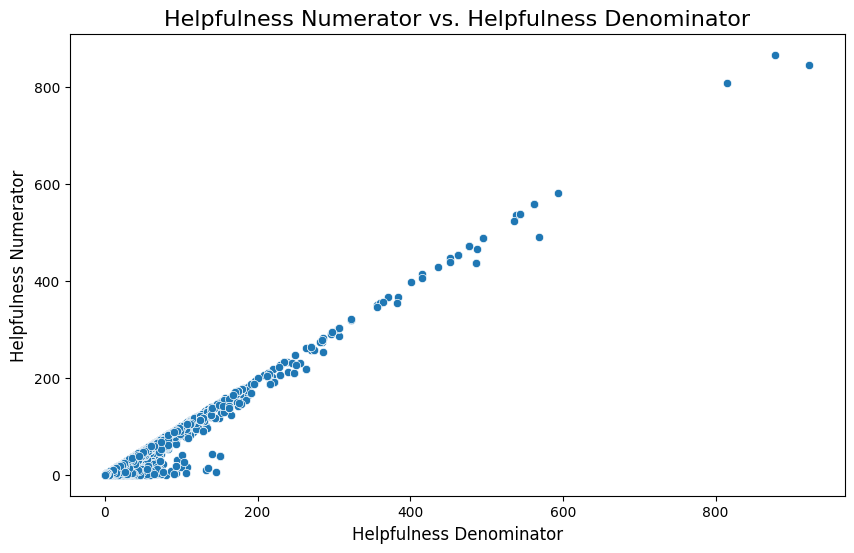

In [ ]:
# Let's look into helfulness numerator vs helpfulness denominator

import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(10, 6))

# Create a scatter plot
sns.scatterplot(x='HelpfulnessDenominator', y='HelpfulnessNumerator', data=df)

# Add title and labels
plt.title('Helpfulness Numerator vs. Helpfulness Denominator', fontsize=16)
plt.xlabel('Helpfulness Denominator', fontsize=12)
plt.ylabel('Helpfulness Numerator', fontsize=12)

# Show the plot
plt.show()


In [ ]:
# Find rows where HelpfulnessNumerator is greater than HelpfulnessDenominator
invalid_helpfulness_rows = df_deduplicated[df_deduplicated['HelpfulnessNumerator'] > df_deduplicated['HelpfulnessDenominator']]

# Display the count of such rows
print(f"Number of rows where HelpfulnessNumerator is greater than HelpfulnessDenominator: {invalid_helpfulness_rows.shape[0]}")


Number of rows where HelpfulnessNumerator is greater than HelpfulnessDenominator: 2


In [ ]:
# Display the rows where HelpfulnessNumerator is greater than HelpfulnessDenominator
invalid_helpfulness_rows


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Year
44736,44737,B001EQ55RW,A2V0I904FH7ABY,Ram,3,2,positive,2008-06-08,Pure cocoa taste with crunchy almonds inside,It was almost a 'love at first bite' - the per...,2008
64421,64422,B000MIDROQ,A161DK06JJMCYF,"J. E. Stephens ""Jeanne""",3,1,positive,2008-10-25,Bought This for My Son at College,My son loves spaghetti so I didn't hesitate or...,2008


- This is mathematically incorrect as the helpfulnessNumerator cannot be greater than Helpfulness Denominator.
- Hence, removing these two rows.

In [ ]:
# Remove rows where HelpfulnessNumerator is greater than HelpfulnessDenominator
df_cleaned = df_deduplicated[df_deduplicated['HelpfulnessNumerator'] <= df_deduplicated['HelpfulnessDenominator']]

# Display the shape of the new DataFrame to confirm the removal
print(f"Shape of the cleaned DataFrame: {df_cleaned.shape}")


Shape of the cleaned DataFrame: (364154, 11)


# Some More Visualisations

<ipython-input-167-574de277c723>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x=score_counts.index, y=score_counts.values, palette='coolwarm')


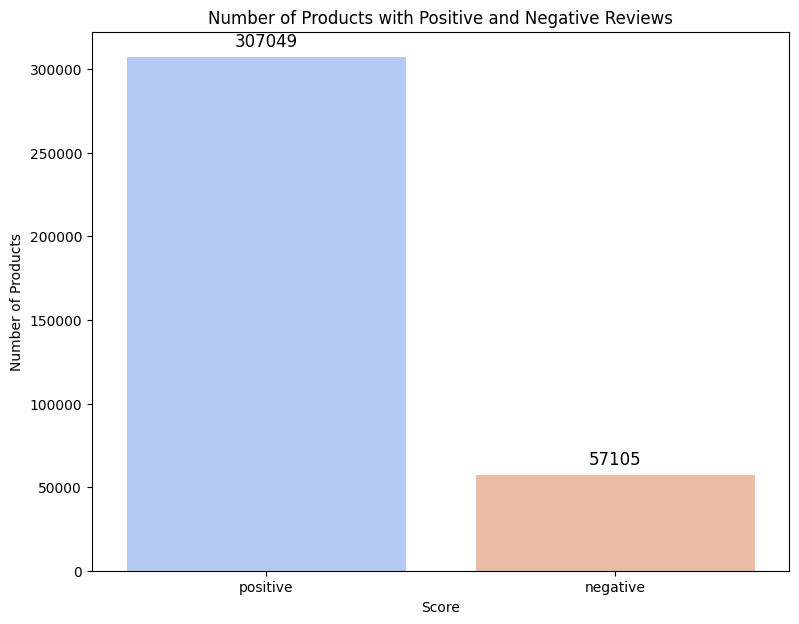

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of products for each score
score_counts = df_cleaned['Score'].value_counts()

# Create a bar plot
plt.figure(figsize=(9, 7))
bar_plot = sns.barplot(x=score_counts.index, y=score_counts.values, palette='coolwarm')
plt.title('Number of Products with Positive and Negative Reviews')
plt.xlabel('Score')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)  # Optional: Rotate x-axis labels for better readability

# Add counts on top of the bars
for p in bar_plot.patches:
    bar_plot.annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom',
                      fontsize=12, color='black',
                      xytext=(0, 5),
                      textcoords='offset points')

plt.show()


In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 364154 entries, 0 to 568453
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Id                      364154 non-null  int64         
 1   ProductId               364154 non-null  object        
 2   UserId                  364154 non-null  object        
 3   ProfileName             364154 non-null  object        
 4   HelpfulnessNumerator    364154 non-null  int64         
 5   HelpfulnessDenominator  364154 non-null  int64         
 6   Score                   364154 non-null  object        
 7   Time                    364154 non-null  datetime64[ns]
 8   Summary                 364154 non-null  object        
 9   Text                    364154 non-null  object        
 10  Year                    364154 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(3), object(6)
memory usage: 32.0+ MB


<ipython-input-171-27dbb71fe450>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['review_length'] = df_cleaned['Text'].apply(lambda x: len(str(x).split())).values


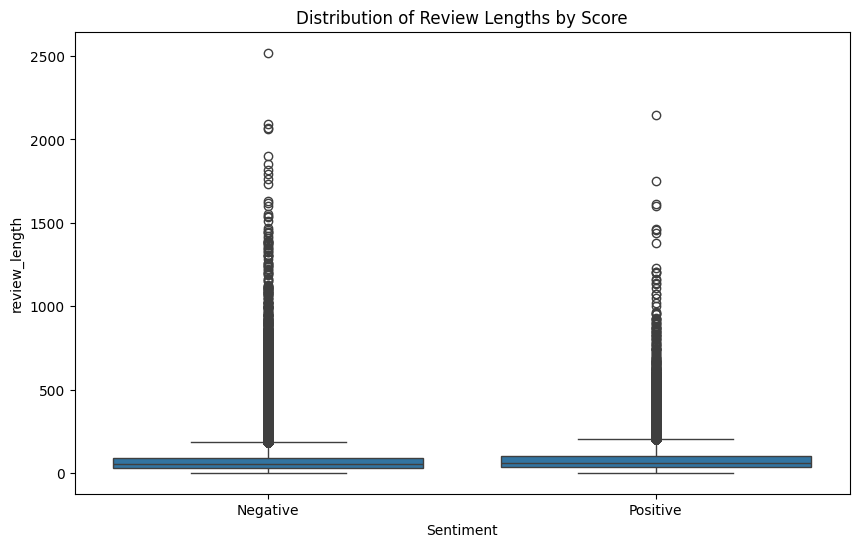

In [ ]:

# Review length distribution by sentiment
#df_cleaned['review_length'] = df_cleaned['Text'].apply(lambda x: len(str(x).split()))
df_cleaned['review_length'] = df_cleaned['Text'].apply(lambda x: len(str(x).split())).values
plt.figure(figsize=(10, 6))
sns.boxplot(x='Score', y='review_length', data=df_cleaned)
plt.title('Distribution of Review Lengths by Score')
plt.xlabel('Sentiment')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()


- The box plot compares **review lengths** (Y-axis) for **Positive** and **Negative sentiments** (X-axis), showing that most reviews are short, but some outliers are significantly longer (up to 2500 words/characters).  
- **Positive reviews** tend to have a slightly higher median length than negative reviews, indicating users often provide more detailed feedback for positive experiences.  
- Both sentiments include **outliers** with unusually long reviews, reflecting detailed feedback from some users about their experiences.  

In [ ]:

## User Behavior Analysis

user_review_counts = df_cleaned['UserId'].value_counts()
users_with_50plus_reviews = user_review_counts[user_review_counts > 50]
print(f"Number of users with more than 50 reviews: {len(users_with_50plus_reviews)}")


Number of users with more than 50 reviews: 92


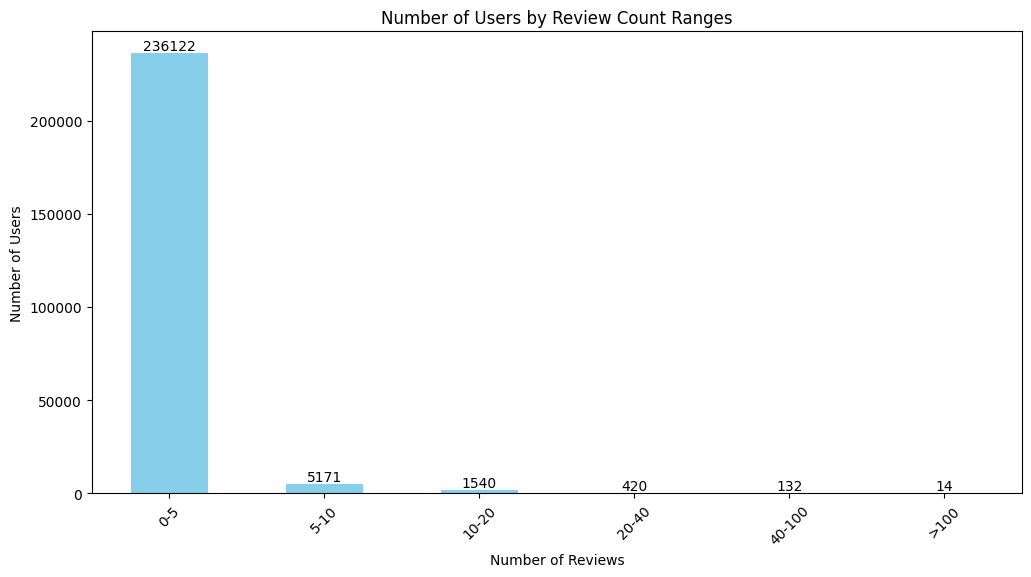

count
0-5       236122
5-10        5171
10-20       1540
20-40        420
40-100       132
>100          14
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Count reviews per user
user_review_counts = df_cleaned['UserId'].value_counts()

# Define review count ranges
bins = [0, 5, 10, 20, 40, 100, float('inf')]  # The last bin captures >100
labels = ['0-5', '5-10', '10-20', '20-40', '40-100', '>100']  # Labels for the bins

# Create a DataFrame to hold counts
review_counts_range = pd.cut(user_review_counts, bins=bins, right=False, labels=labels)
user_counts_range = review_counts_range.value_counts().sort_index()

# Plotting the range-wise count of user IDs
plt.figure(figsize=(12, 6))
user_counts_range.plot(kind='bar', color='skyblue')
plt.title('Number of Users by Review Count Ranges')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Add counts on top of the bars
for index, value in enumerate(user_counts_range):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()

# Display the counts in each range
print(user_counts_range)


- The majority of users (236,122) fall into the **0-5 reviews range**, showing that most users are casual reviewers.  
- The number of users decreases sharply as review counts increase, with only **14 users** contributing more than 100 reviews.  
- This distribution highlights that a small group of users are highly active, while most contribute very few reviews.  
- Prolific reviewers may have a disproportionate influence on product ratings and overall dataset trends.

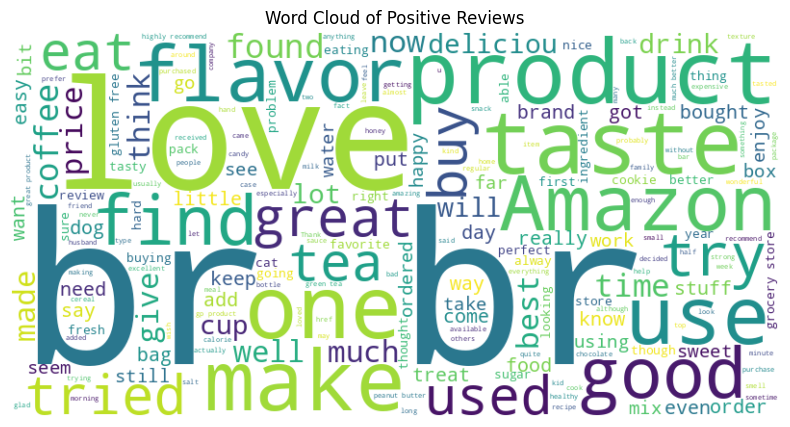

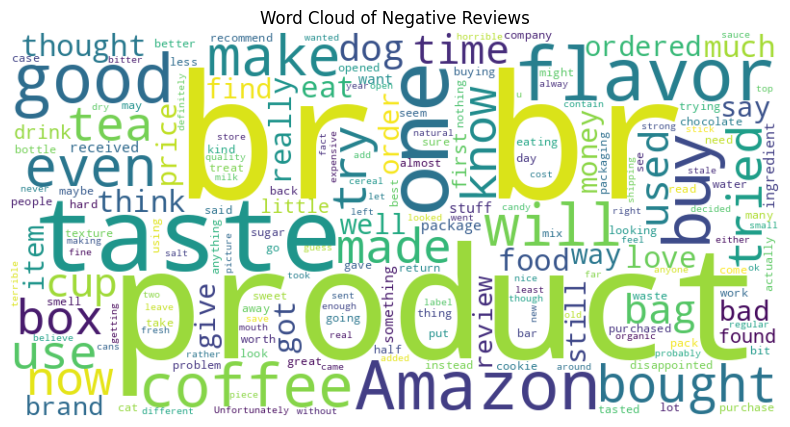

In [ ]:
from wordcloud import WordCloud
## Text Analysis

# Word cloud for positive and negative reviews
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

positive_text = ' '.join(df_cleaned[df_cleaned['Score'] == 'positive']['Text'].astype(str))
negative_text = ' '.join(df_cleaned[df_cleaned['Score'] == 'negative']['Text'].astype(str))

generate_wordcloud(positive_text, 'Word Cloud of Positive Reviews')
generate_wordcloud(negative_text, 'Word Cloud of Negative Reviews')


- The **positive reviews** (top word cloud) highlight words like **"love," "great," "flavor," "delicious,"** and **"product,"** reflecting customer satisfaction with product quality and taste.  
- The **negative reviews** (bottom word cloud) focus on words like **"taste," "flavor," "bad," "disappointed,"** and **"cost,"** indicating dissatisfaction with product attributes or pricing.  
- Common words across both clouds, such as **"flavor," "taste,"** and **"product,"** show that customers consistently focus on these key aspects, regardless of sentiment.  
- Positive reviews often use emotional and affirmative language like **"love"** and **"delicious,"** while negative reviews emphasize problems with words like **"bad"** and **"disappointed."**  
- These word clouds provide actionable insights: strengths like product taste and satisfaction stand out in positive reviews, while areas like pricing or specific product flaws dominate negative feedback.  

In [ ]:
# Save the cleaned DataFrame to a CSV file
df_cleaned.to_csv("df_cleaned.csv", index=False)
print("The cleaned DataFrame has been saved as 'df_cleaned.csv'.")


The cleaned DataFrame has been saved as 'df_cleaned.csv'.
